# A Predator-Prey Model

## Model Description

Suppose there is a population of rabbits (prey) and a population of foxes (predators) that inhabit the same area. The sizes of these two populations can be modeled as a system of ordinary differential equations (ODEs). In particular, if $x$ and $y$ represent the numbers (in thousands) of rabbits and foxes, respectively, the rates of change of these numbers can be estimated as  
$$
\begin{aligned}
  \frac{\mathrm{d}x}{\mathrm{d}t} &= \alpha x - \beta x y \\
  \frac{\mathrm{d}y}{\mathrm{d}t} &= \gamma x y - \delta y \\
\end{aligned}
$$

where $\alpha$ ($d^{-1}$) is a parameter that determines the birth rate of rabbits, $\beta$ ($d^{-1}$ per 1000 foxes) is a parameter that determines the death rate of rabbits, $\gamma$ ($d^{-1}$ per 1000 rabbits) is a parameter that determines the birth rate of foxes, and $\delta$ ($d^{-1}$) is a parameter that determines the death rate of foxes. In order to solve an initial value problem for the predator-prey model, one needs to provide the values of $\alpha$, $\beta$, $\gamma$, and $\delta$, as well as initial values for $x$ and $y$.

## MCSim Model Specification

We used the [GNU MCSim](https://www.gnu.org/software/mcsim/) model specification language to implement the predator-prey model. The complete MCSim model specification file for this model, `pred_prey.model`, can be found in the `extdata` subdirectory of the **MCSimMod** package installation directory.

In the model specification file, the text symbols `x` and `y` are used to represent the state variables $x$ and $y$ and the text symbols `alpha`, `beta`, `gamma`, and `delta` are used to represent the parameters $\alpha$, $\beta$, $\gamma$, and $\delta$, respectively.

## Building the Model

First, we load the **PyMCSimMod** package as follows.

In [1]:
%load_ext autoreload
%autoreload 2

from pymcsimmod import create_model

Using the following commands, we create a model object (i.e., an instance of the `JaxModel` class) using the model specification file `pred_prey.model` that is included in the **PyMCSimMod** package. For this example, we will use the JAX backend to perform model simulations.

In [2]:
import importlib.resources
with importlib.resources.path('pymcsimmod.data', 'pred_prey.model') as filename:
    pp_mod = create_model(filename, backend="jax")

## Predicting the Numbers of Rabbits and Foxes

Suppose we want to predict the numbers of rabbits and foxes over a period of 50 days assuming that $\alpha = 0.67$, $\beta = 1.33$, $\gamma = 1.00$, $\delta = 1.00$, and the initial numbers of rabbits and foxes are 1000 and 750, respectively. These are the default values of the model parameters and initial conditions that are provided in the model specification file, and we can verify this with the following commands.

In [3]:
print(pp_mod.parameters)
print(pp_mod.Y0)

{'alpha': 0.67, 'beta': 1.33, 'gamma': 1.0, 'delta': 1.0}
{'x': 1.0, 'y': 0.75}


We can perform a simulation that provides results for the desired output times (i.e., $t = 0.0, 0.1, 0.2, \ldots, 50.0$) using the following commands.

In [4]:
import numpy as np

# Define output times for simulation.
times = np.arange(start = 0, stop = 50, step = 0.1)

# Run simulation.
results = pp_mod.run_model(times)
out = results.dataframe

## Examining the Results

The final command shown above, `results = pp_mod.run_model(times)`,  performs a model simulation and stores the simulation results in a `ComputedModel` object. The resulting simulation results are obtained as a pandas dataframe called `out`. There is one row for each output time, and one column for each state variable. The first five rows of this data structure are shown below. Note that the independent variable, which is $t$ in the case of the predator-prey model, is always labeled "time" in the output data structure.

In [5]:
display(out.head())

,time,x,y
0,0.0,1.000000,0.750000
1,0.1,0.967833,0.748787
2,0.2,0.936999,0.745224
3,0.3,0.907713,0.739449
4,0.4,0.880138,0.731637


We can create visual representations of the simulation results. For example, we can plot the numbers of rabbits and foxes vs. time using the following commands.

We can use the `labels` argument of the `plot_results` method to provide custom labels for the plot axes and legend. For example, the following commands create a plot with more descriptive axis labels and legend entries.

(0.0, 2.0)

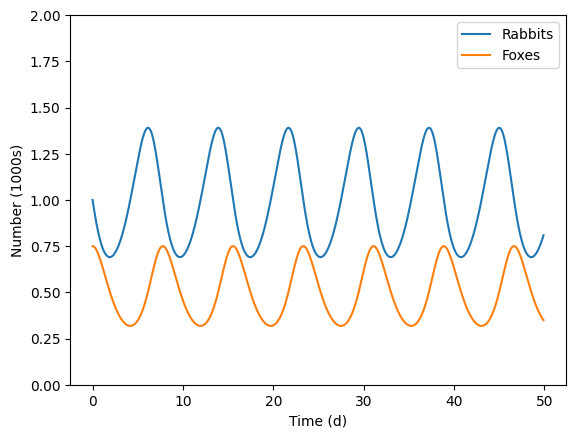

In [6]:
ax = results.plot_results(variables=['x', 'y'], labels={'x': 'Rabbits', 'y': 'Foxes'}, xlabel='Time (d)', ylabel="Number (1000s)")
ax.set_ylim([0, 2])

Alternatively, we can plot the results in phase-space as follows.

Text(0, 0.5, 'Number of Foxes (1000s)')

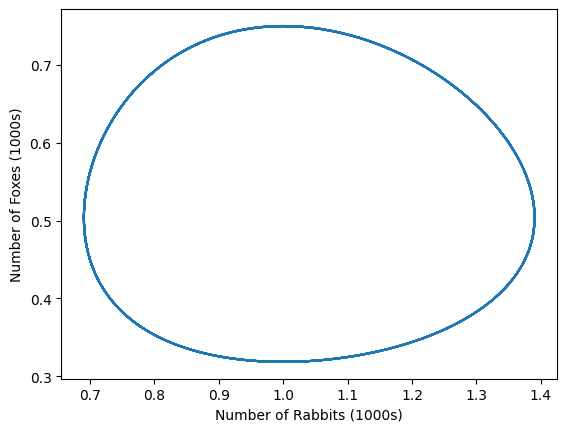

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1)
ax.plot(out['x'], out['y'])
ax.set_xlabel('Number of Rabbits (1000s)')
ax.set_ylabel('Number of Foxes (1000s)')